In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
import os

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

df = pd.read_csv('data/processed/nba_model_data.csv')
print(f"Loaded: {df.shape}")
print(df[['PLAYER_NAME','ERA','MPG','HEIGHT_IN','WEIGHT','AGE','FG3A_RATE','FTA_RATE','PLUS_MINUS']].head())


Loaded: (6567, 80)
     PLAYER_NAME     ERA   MPG  HEIGHT_IN  WEIGHT   AGE  FG3A_RATE  FTA_RATE  \
0   Aaron Gordon  Modern  27.7       80.0   235.0  25.0   0.350000  0.300000   
1  Aaron Holiday  Modern  17.8       72.0   185.0  24.0   0.424242  0.196970   
2  Aaron Nesmith  Modern  14.5       77.0   215.0  21.0   0.589744  0.153846   
3    Abdel Nader  Modern  14.8       77.0   225.0  27.0   0.375000  0.312500   
4     Al Horford  Modern  27.9       80.0   240.0  35.0   0.418605  0.062016   

   PLUS_MINUS  
0         1.2  
1         0.0  
2        -0.2  
3         1.2  
4        -3.6  


In [2]:
features = ['MPG', 'HEIGHT_IN', 'WEIGHT', 'AGE', 'FG3A_RATE', 'FTA_RATE', 'PLUS_MINUS']

df_model = df[features].dropna()
print(f"Rows after dropping NA: {len(df_model)} (dropped {len(df) - len(df_model)})")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_model)
print(f"Scaled shape: {X_scaled.shape}")


Rows after dropping NA: 6471 (dropped 96)
Scaled shape: (6471, 7)


In [3]:
km = KMeans(n_clusters=15, random_state=109)
km.fit(X_scaled)
df_model = df_model.copy()
df_model['CLUSTER'] = km.labels_
print(f"Inertia: {km.inertia_:.1f}")
print(f"\nCluster sizes:\n{df_model['CLUSTER'].value_counts().sort_index()}")

# Cluster centers (for interpretation)
centers = pd.DataFrame(scaler.inverse_transform(km.cluster_centers_), columns=features)
centers['CLUSTER'] = range(15)
centers = centers[['CLUSTER'] + features]
print("\nCluster centers:")
print(centers.round(1).to_string())


Inertia: 16702.5

Cluster sizes:
CLUSTER
0     579
1     370
2     414
3     391
4     384
5     374
6     403
7     372
8     462
9     409
10    270
11    625
12    478
13    508
14    432
Name: count, dtype: int64

Cluster centers:
    CLUSTER   MPG  HEIGHT_IN  WEIGHT   AGE  FG3A_RATE  FTA_RATE  PLUS_MINUS
0         0  13.8       79.1   216.9  23.6        0.5       0.2        -0.9
1         1  33.3       75.7   202.0  28.3        0.4       0.3         4.7
2         2  14.6       77.4   207.5  24.5        0.2       0.4        -0.7
3         3  18.2       79.9   230.3  32.7        0.6       0.2        -0.3
4         4  30.9       82.5   252.4  28.8        0.1       0.4         3.7
5         5  25.5       77.4   209.7  27.9        0.6       0.2         2.2
6         6  19.5       74.7   192.3  33.3        0.4       0.2        -0.7
7         7  27.6       82.1   250.1  24.8        0.1       0.4        -2.8
8         8  27.0       78.0   210.6  23.8        0.4       0.2        -4.7
9    

In [4]:
cluster_names = {
    0:  "Bench Slasher",           # young, low MPG, tall, low usage
    1:  "Playmaking Shot Creator", # high MPG, guard, high plus/minus
    2:  "Paint Beast",             # low MPG, mid height, foul-drawer
    3:  "Stretch Glass Cleaner",   # veteran, tall, 3PT rate high
    4:  "2-Way Facilitator",       # elite center, high MPG, high plus/minus
    5:  "3-Level Scorer",          # mid MPG, wing, high 3PT rate
    6:  "Veteran Lockdown",        # old, low MPG, guard
    7:  "Rim Protector",           # young center, high MPG, negative plus/minus
    8:  "Scoring Machine",         # high MPG, young wing, negative plus/minus
    9:  "Post Facilitator",        # veteran backup big, low MPG
    10: "Glass Cleaning Finisher", # bench center, high FTA rate
    11: "Inside Finisher",         # young bench big, low 3PT rate
    12: "2-Way Sharpshooter",      # bench guard, young
    13: "3-Level Big",          # prime starting big, positive plus/minus
    14: "Shot Creator",            # high MPG, average guard
}

In [5]:
df_model['CLUSTER_NAME'] = df_model['CLUSTER'].map(cluster_names)

# Save cluster centers and sizes
os.makedirs('results', exist_ok=True)
centers['CLUSTER_NAME'] = centers['CLUSTER'].map(cluster_names)
centers.to_csv('results/cluster_centers.csv', index=False)
df_model['CLUSTER'].value_counts().sort_index().to_csv('results/cluster_sizes.csv')
print("Saved results/cluster_centers.csv and results/cluster_sizes.csv")


Saved results/cluster_centers.csv and results/cluster_sizes.csv


                                 Mean_Missed_Rate  Median_Missed_Rate    N
CLUSTER CLUSTER_NAME                                                      
12      2-Way Sharpshooter                  0.455               0.442  478
0       Bench Slasher                       0.448               0.458  579
10      Glass Cleaning Finisher             0.441               0.455  270
2       Paint Beast                         0.425               0.416  414
11      Inside Finisher                     0.413               0.378  625
9       Post Facilitator                    0.357               0.329  409
6       Veteran Lockdown                    0.341               0.301  403
3       Stretch Glass Cleaner               0.340               0.301  391
8       Scoring Machine                     0.282               0.232  462
7       Rim Protector                       0.205               0.129  372
5       3-Level Scorer                      0.194               0.134  374
14      Shot Creator     

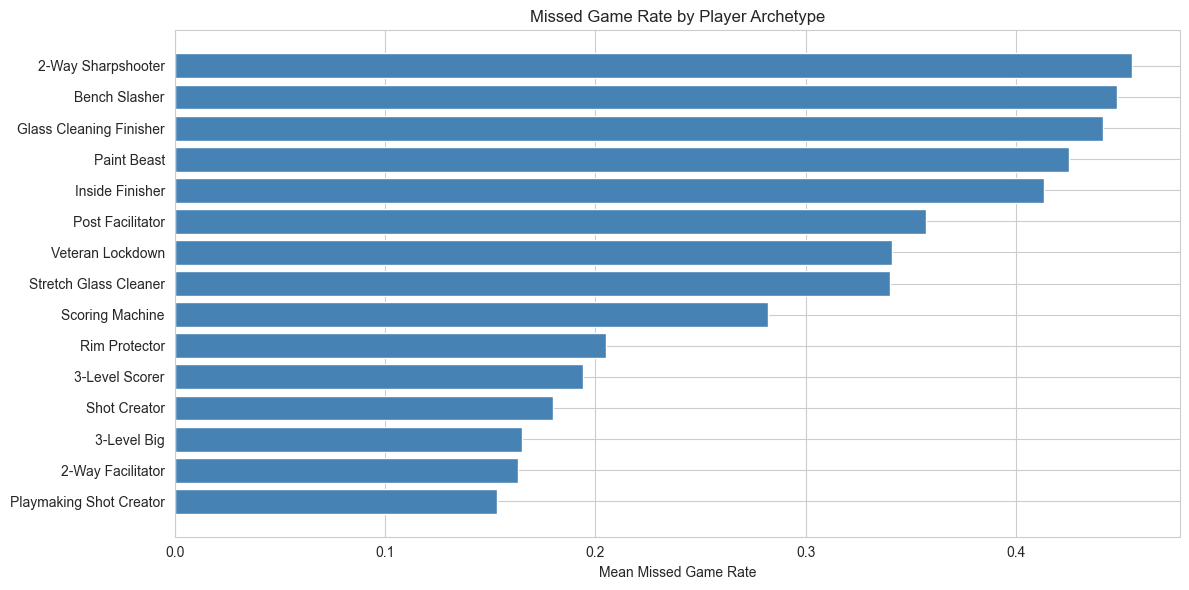

Saved figures/missed_games_by_cluster.png and results/cluster_missed_game_summary.csv


In [6]:
df_full = df.loc[df_model.index].copy()
df_full['CLUSTER'] = df_model['CLUSTER']
df_full['CLUSTER_NAME'] = df_model['CLUSTER_NAME']

cluster_summary = df_full.groupby(['CLUSTER','CLUSTER_NAME'])['MISSED_GAME_RATE'].agg(['mean','median','count']).round(3)
cluster_summary.columns = ['Mean_Missed_Rate','Median_Missed_Rate','N']
cluster_summary = cluster_summary.sort_values('Mean_Missed_Rate', ascending=False)
print(cluster_summary.to_string())

os.makedirs('figures', exist_ok=True)
fig, ax = plt.subplots(figsize=(12,6))
sorted_df = cluster_summary.reset_index().sort_values('Mean_Missed_Rate', ascending=True)
ax.barh(sorted_df['CLUSTER_NAME'], sorted_df['Mean_Missed_Rate'], color='steelblue')
ax.set_xlabel('Mean Missed Game Rate')
ax.set_title('Missed Game Rate by Player Archetype')
plt.tight_layout()
plt.savefig('figures/missed_games_by_cluster.png', dpi=150)
plt.show()

cluster_summary.to_csv('results/cluster_missed_game_summary.csv')
print("Saved figures/missed_games_by_cluster.png and results/cluster_missed_game_summary.csv")


In [7]:
df_clustered = df.copy()
df_clustered.loc[df_model.index, 'CLUSTER'] = df_model['CLUSTER']
df_clustered.loc[df_model.index, 'CLUSTER_NAME'] = df_model['CLUSTER_NAME']

df_clustered.to_csv('data/processed/nba_model_data_clustered.csv', index=False)
print(f"Saved: data/processed/nba_model_data_clustered.csv  {df_clustered.shape}")

Saved: data/processed/nba_model_data_clustered.csv  (6567, 82)
